# Bayesian Logistic Regression and Laplace Approximation

## **Objective**
In this exercise, you will explore **Bayesian inference** in logistic regression using **Laplace approximation**. Specifically, you will:
1. Compute the **posterior distribution** for logistic regression coefficients.
2. Use **maximum a posteriori (MAP) estimation** to find the most probable coefficients.
3. Compute and visualize the **Laplace approximation** to the posterior.

The dataset is already provided.

---

## **1. Bayesian Logistic Regression**
### **(a) Define the posterior distribution in Bayesian logistic regression**
- The posterior distribution for the logistic regression coefficients $ b $ is:

  $$
  P(b | X, y) \propto P(y | X, b) P(b)
  $$

  where:
  - $ P(y | X, b) $ is the **likelihood**, modeled using logistic regression.
  - $ P(b) $ is the **prior**, assumed to be a **Gaussian**:  
    $$
    P(b) = \mathcal{N}(0, I)
    $$

### **(b) Implement the log-posterior function**
- The **log-posterior** is given by:

  $$
  \log P(b | X, y) = \sum_{i} y_i \log \sigma(X_i b) + (1 - y_i) \log (1 - \sigma(X_i b)) - \frac{1}{2} b^T b
  $$

  where $ \sigma(z) = \frac{1}{1 + e^{-z}} $ is the **sigmoid function**.

---

## **2. Finding the Mode of the Posterior (MAP Estimation)**
### **(a) Use numerical optimization to maximize the log-posterior**
- Use **`scipy.optimize.minimize`** to find the **mode of the posterior** (maximum a posteriori estimate).
- Initialize parameters and apply the **BFGS optimization method**.

### **(b) Explain how the Hessian matrix helps estimate uncertainty**
- The inverse Hessian matrix ($ H^{-1} $) provides an **approximation of the posterior covariance**.
- What does this tell us about **parameter uncertainty**?

---

## **3. Laplace Approximation**
### **(a) Explain the Laplace approximation**
- The **posterior distribution** is often **non-Gaussian**, but can be approximated by a Gaussian centered at the **MAP estimate**.
- The Laplace approximation assumes:

  $$
  P(b | X, y) \approx \mathcal{N}(b_{\text{mode}}, H^{-1})
  $$

  where $ b_{\text{mode}} $ is the **MAP estimate** and $ H^{-1} $ is the **Hessian inverse**.

### **(b) Implement the Laplace approximation**
- Compute the Laplace approximation at the **MAP estimate**.
- Use **multivariate normal density function** to approximate the posterior.

### **(c) Compare the true posterior surface and the Laplace approximation**
- **Visualize both** using **contour plots**.
- Discuss: **How well does the Laplace approximation match the true posterior?**


Laplace approximation is a technique used in Bayesian inference to approximate complex posterior distributions.

In [ ]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
X, y = make_blobs(n_samples=100, centers=2, n_features=2,
                  random_state=42, cluster_std=6)

# Log of the posterior in Bayesian logistic regression

## **Bayes' Theorem and Log-Posterior Transformation**
From **Bayes' Theorem**, the posterior distribution is given by:

$$
P(b \mid X, y) \propto P(y \mid X, b) P(b)
$$

Taking the **logarithm** on both sides:

$$
\log P(b \mid X, y) = \log P(y \mid X, b) + \log P(b) + C
$$

where:
- **$ P(y \mid X, b) $** is the **likelihood** (how well the data fits the model).
- **$ P(b) $** is the **prior** (our belief about $ b $ before seeing data).
- **$ C $** is a **normalization constant** (does not affect optimization).

## **Log-Prior Expression**
This expression represents the **log of a multivariate Gaussian prior**:

$$
\log P(b) = -\frac{1}{2} (b - \mu)^T \Sigma^{-1} (b - \mu)
$$

where:
- **$ b $** = parameter vector (logistic regression coefficients).
- **$ \mu $** = `prior_mean`, the **mean vector of the prior**.
- **$ \Sigma $** = `prior_covariance`, the **covariance matrix of the prior**.
- **$ \Sigma^{-1} $** = **inverse covariance matrix** (precision matrix).

---

## **Simplification in Our Case**
Since we assume:
- **$ \mu = 0 $** (zero mean prior).
- **$ \Sigma = I $** (identity covariance matrix, meaning no correlation between parameters).

The formula simplifies to:

$$
\log P(b) = -\frac{1}{2} b^T b
$$

which is exactly what the code computes.


# Likelihood and Log-Likelihood in Bayesian Logistic Regression

## **1. Likelihood Function**
In logistic regression, the **likelihood function** represents the probability of the observed labels **$ y $** given the inputs **$ X $** and parameters **$ b $**:

$$
P(y \mid X, b) = \prod_{i=1}^{N} P(y_i \mid X_i, b)
$$

For binary classification (**$ y \in \{0,1\} $**), we define the probability using the **sigmoid function**:

$$
P(y_i = 1 \mid X_i, b) = \sigma(X_i b) = \frac{1}{1 + e^{-X_i b}}
$$

$$
P(y_i = 0 \mid X_i, b) = 1 - \sigma(X_i b)
$$

Thus, the full **likelihood function** is:

$$
L(b) = \prod_{i=1}^{N} \sigma(X_i b)^{y_i} (1 - \sigma(X_i b))^{(1 - y_i)}
$$

where:
- **$ X_i $** is the input for the **$ i $**-th data point.
- **$ b $** is the parameter vector (**logistic regression coefficients**).
- **$ \sigma(z) $** is the **sigmoid function**:

  $$
  \sigma(z) = \frac{1}{1 + e^{-z}}
  $$

---

## **2. Log-Likelihood Function**
Since taking the logarithm simplifies calculations and prevents numerical underflow, the **log-likelihood function** is:

$$
\log L(b) = \sum_{i=1}^{N} \left[ y_i \log \sigma(X_i b) + (1 - y_i) \log (1 - \sigma(X_i b)) \right]
$$



In [ ]:
#b: candidate parameter
def log_posterior(b, y, X):
    N = len(b) # number of coefficients - 2 in this case
    #we assume no strong preference for any particular values of b
    prior_mean = np.zeros(N) # mean vector of the prior distribution
    #we assume each parameter is equally uncertain before seeing data.
    #If off-diagonal elements were nonzero,
    #           it would mean parameters are correlated in the prior belief.
    prior_covariance = np.eye(N) # covariance on b - identity matrix

    pi = 1/(1 + np.exp(-X.dot(b))) # Sigmoid: convert unbound values to probability [Week4]

    # log of multivariate normal distribution
    prior = -0.5 * (b - prior_mean).dot(np.linalg.inv(prior_covariance)).dot(b - prior_mean)
    likelihood = np.sum(y * np.log(pi) + (1-y)*np.log(1-pi)) # logistic regression
    return -prior - likelihood # negative log posterior

# Mode and Hessian Calculations

## ** Why Take the Inverse of `results.hess_inv`?**
Since `results.hess_inv` is already the **inverse Hessian**, taking its inverse gives us back the **original Hessian**:

$$
H = \left( H^{-1} \right)^{-1}
$$

This step is necessary because:
- Some approximations (like the **Laplace approximation**) require the **Hessian itself**.
- The Hessian is used to **understand how sharp the posterior is at the MAP estimate**.


In [ ]:
# by maximising the posterior on b (coefficients of the model)
from scipy.optimize import minimize, brute
#brute: exhaustive grid search over the range defined in rranges

initial_guess = [1,1]
results = minimize(log_posterior,initial_guess,args = (y,X),method = 'BFGS')
b_mode = results.x # mode after maximising the log posterior

print(b_mode)
# b_mode: optimized parameter values.
print(results.hess_inv)
# results.hess_inv: estimate uncertainty
# Smaller diagonal values indicate higher certainty.
# Off-Diagonal Elements:
# strong/weak positive/negative correlation

[ 0.32083871 -0.08857936]
[[ 0.00419416 -0.00053874]
 [-0.00053874  0.00114695]]


<ipython-input-7-9eff046558d4>:15: RuntimeWarning: divide by zero encountered in log
  likelihood = np.sum(y * np.log(pi) + (1-y)*np.log(1-pi)) # logistic regression
/usr/local/lib/python3.11/dist-packages/scipy/optimize/_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


# Function for the laplace approximation

In [ ]:
# Explain how the Hessian matrix helps estimate uncertainty
# Be careful! This is hessian, not inverse hessian.
hessian = np.linalg.inv(results.hess_inv)#Use later in Laplace function

# assuming a Gaussian posterior.
def laplace_approx(b, b_mode, H):
    #Week3 Written_notes:Laplace Approximation-D-dimensional
    detH =  np.linalg.det(H) # determinant of Hessian matrix
    constant = np.sqrt(detH)/(2*np.pi)**(2.0/2.0) # Normalisation constant
    density = np.exp(-0.5 * (b-b_mode).dot(H).dot(b-b_mode)) # multivariate normal distribution
    return constant * density

# Laplace Approximation in Bayesian Inference

## **Mathematical Equation for `laplace_approx`**
The function `laplace_approx(b, b_mode, H)` approximates the **posterior distribution** using the **Laplace approximation**, which assumes a **Gaussian distribution** centered at the Maximum A Posteriori (MAP) estimate.

---

## **1. Laplace Approximation Formula**
The Laplace approximation models the posterior as a **multivariate normal distribution**:

$$
P(b \mid X, y) \approx \mathcal{N}(b_{\text{mode}}, H^{-1})
$$

where:
- **$ b_{\text{mode}} $** is the **MAP estimate** (mode of the posterior).
- **$ H^{-1} $** is the **inverse Hessian matrix**, which approximates the **posterior covariance**.

The probability density function of a **multivariate normal distribution** is:

$$
P(b) = \frac{\sqrt{\det H}}{(2\pi)^{N/2}} \exp \left( -\frac{1}{2} (b - b_{\text{mode}})^T H (b - b_{\text{mode}}) \right)
$$

where:
- **$ H $** is the **Hessian matrix of the negative log-posterior**.
- **$ \det H $** is the **determinant of the Hessian matrix**.
- **$ N $** is the **number of parameters (dimensionality of $ b $)**.
- The **exponential term** represents the quadratic form of a **Gaussian density function**.


# Visualisation of posterior and laplace approximation

<ipython-input-7-9eff046558d4>:15: RuntimeWarning: divide by zero encountered in log
  likelihood = np.sum(y * np.log(pi) + (1-y)*np.log(1-pi)) # logistic regression
<ipython-input-7-9eff046558d4>:15: RuntimeWarning: invalid value encountered in multiply
  likelihood = np.sum(y * np.log(pi) + (1-y)*np.log(1-pi)) # logistic regression
<ipython-input-10-32e849f93285>:13: RuntimeWarning: divide by zero encountered in log
  neg_log_laplace = -np.log(laplace_surface[3])


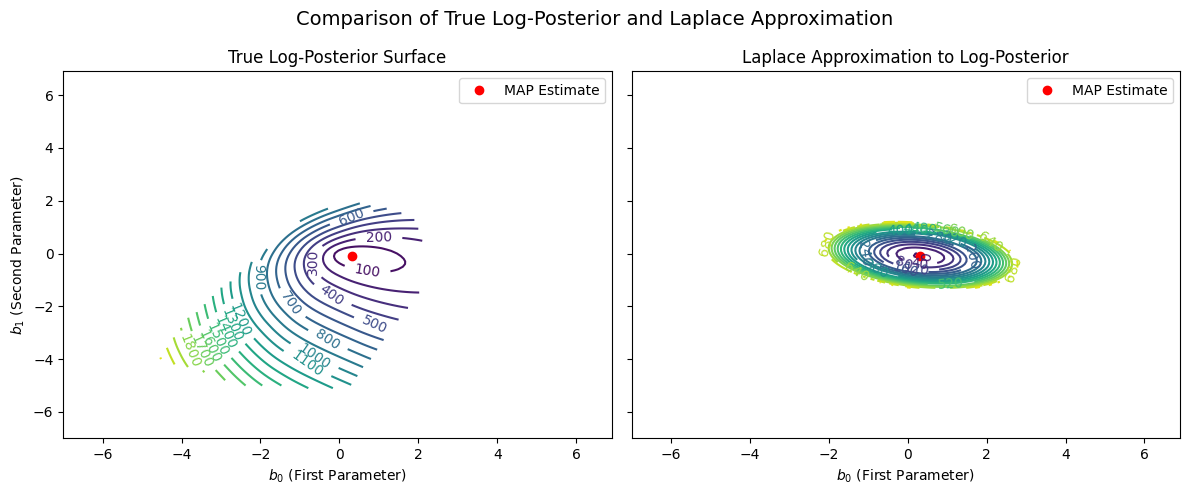

'\n1.Smaller contour values → Higher probability (better parameter estimates).\n2.The closer the contour lines are together → The steeper the probability surface (sharp peak).\n3.If the left plot is irregular but the right plot is smooth,\n     the Laplace approximation is oversimplifying the true posterior.\n'

In [ ]:
#Define the Search Grid for Parameters
rranges = (slice(-7, 7, 0.1), slice(-7, 7, 0.1))
#brute-force optimization to evaluate the log_posterior on a grid of values
#Computes the posterior surface by evaluating log_posterior or each combination b0 and b1
#brute function: optimizes over the first argument
grid_sol = brute(log_posterior, rranges, args=(y, X),full_output=True)
# pull out components
b_i0, b_i1, log_posterior_surface = grid_sol[2][0], grid_sol[2][1],  grid_sol[3]

# we'll do the same for the laplace approximation
# Compute the Laplace Approximation Surface
laplace_surface = brute(laplace_approx, rranges, args=(b_mode, hessian),full_output=True)
neg_log_laplace = -np.log(laplace_surface[3])

# Create Contour Plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plot the True Log-Posterior Surface
CS1 = ax[0].contour(b_i0, b_i1, log_posterior_surface, cmap='viridis', levels=20)
ax[0].clabel(CS1, inline=1, fontsize=10)
ax[0].plot(b_mode[0], b_mode[1], 'ro', label="MAP Estimate")
ax[0].set_title("True Log-Posterior Surface")
ax[0].set_xlabel("$b_0$ (First Parameter)")
ax[0].set_ylabel("$b_1$ (Second Parameter)")
ax[0].legend()

# Plot the Laplace Approximation Surface
CS2 = ax[1].contour(b_i0, b_i1, neg_log_laplace, cmap='viridis', levels=20)
ax[1].clabel(CS2, inline=1, fontsize=10)
ax[1].plot(b_mode[0], b_mode[1], 'ro', label="MAP Estimate")
ax[1].set_title("Laplace Approximation to Log-Posterior")
ax[1].set_xlabel("$b_0$ (First Parameter)")
ax[1].legend()

plt.suptitle("Comparison of True Log-Posterior and Laplace Approximation", fontsize=14)
plt.tight_layout()
plt.show()

"""
1.Smaller contour values → Higher probability (better parameter estimates).
2.The closer the contour lines are together → The steeper the probability surface (sharp peak).
3.If the left plot is irregular but the right plot is smooth,
     the Laplace approximation is oversimplifying the true posterior.
"""

# Derivation of the Laplace Approximation Formula for $ P(b) $

## **Step 1: Start with Bayes’ Theorem**
Bayesian inference gives us the posterior:

$$
P(b \mid X, y) \propto P(y \mid X, b) P(b)
$$

where:
- **$ P(b \mid X, y) $** is the **posterior** (what we approximate).
- **$ P(y \mid X, b) $** is the **likelihood** (how well $ b $ explains the data).
- **$ P(b) $** is the **prior** (belief about $ b $ before seeing data).

Since we don’t care about the **normalizing constant**, we focus on:

$$
\log P(b \mid X, y) = \log P(y \mid X, b) + \log P(b) + C
$$

where **$ C $** is a constant that does not depend on **$ b $**.

---

## **Step 2: Approximate $ \log P(b \mid X, y) $ with a Taylor Expansion**
Since computing the full posterior is difficult, we approximate it **near its maximum** using a **second-order Taylor expansion**.

1. Find the **Maximum A Posteriori (MAP) estimate**:

   $$
   b_{\text{mode}} = \arg\max_b \log P(b \mid X, y)
   $$

2. Expand $ \log P(b \mid X, y) $ around $ b_{\text{mode}} $:

   $$
   \log P(b \mid X, y) \approx \log P(b_{\text{mode}} \mid X, y) + \frac{1}{2} (b - b_{\text{mode}})^T H (b - b_{\text{mode}})
   $$

   where:
   - **$ H $** is the **Hessian matrix** of the log-posterior:

$$
H = \nabla^2 \log P(b \mid X, y) \Big|_{b_{\text{mode}}}
$$

   - The first-order term **$ \nabla \log P(b) $** disappears at **$ b_{\text{mode}} $** since it's a **maximum**.

---

## **Step 3: Convert Back to Probability Form**
Since **$ P(b \mid X, y) $** is proportional to **$ e^{\log P(b \mid X, y)} $**, we exponentiate both sides:

$$
P(b \mid X, y) \approx P(b_{\text{mode}} \mid X, y) \exp \left( \frac{1}{2} (b - b_{\text{mode}})^T H (b - b_{\text{mode}}) \right)
$$

This resembles the **exponent of a multivariate Gaussian distribution**.

---

## **Step 4: Convert to Multivariate Normal Form**
From probability theory, the probability density function (PDF) of a **multivariate normal distribution** is:

$$
P(b) = \frac{1}{\sqrt{(2\pi)^N \det \Sigma}} \exp \left( -\frac{1}{2} (b - \mu)^T \Sigma^{-1} (b - \mu) \right)
$$

Comparing this with our equation:
- **$ \mu = b_{\text{mode}} $** (MAP estimate as the mean).
- **$ \Sigma = H^{-1} $** (Inverse of the Hessian is the covariance).

Thus, we rewrite:

$$
P(b) = \frac{1}{\sqrt{(2\pi)^N \det H^{-1}}} \exp \left( -\frac{1}{2} (b - b_{\text{mode}})^T H (b - b_{\text{mode}}) \right)
$$

Since:

$$
\det (H^{-1}) = (\det H)^{-1}
$$

We simplify the denominator:

$$
\sqrt{\det H^{-1}} = \frac{1}{\sqrt{\det H}}
$$

Rewriting:

$$
P(b) = \frac{\sqrt{\det H}}{(2\pi)^{N/2}} \exp \left( -\frac{1}{2} (b - b_{\text{mode}})^T H (b - b_{\text{mode}}) \right)
$$

which is the **Laplace approximation formula**.

---

## **Final Equation**
$$
P(b) = \frac{\sqrt{\det H}}{(2\pi)^{N/2}} \exp \left( -\frac{1}{2} (b - b_{\text{mode}})^T H (b - b_{\text{mode}}) \right)
$$

where:
- **$ H $** is the **Hessian matrix** of the log-posterior at $ b_{\text{mode}} $.
- **$ b_{\text{mode}} $** is the **MAP estimate** (posterior mode).
- **$ \det H $** ensures normalization.
- The **exponential term models uncertainty in $ b $**.

---
